# 📧 SMS Spam Classifier
## Complete Machine Learning Project in Google Colab

This notebook trains and evaluates multiple ML models to classify SMS messages as spam or ham.

### 🎯 Features:
- 5 different ML algorithms
- Interactive prediction widget
- Comprehensive visualizations
- 98%+ accuracy

---

## 1️⃣ Install Required Packages

In [ ]:
# Install required packages (most are already in Colab)
!pip install -q ipywidgets

print("✅ All packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.9 MB/s eta 0:00:00
✅ All packages installed!


## 2️⃣ Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Colab
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 3️⃣ Upload Dataset

Upload your `spam.csv` file when prompted.

In [ ]:
print("📂 Please upload your spam.csv file:")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
print(f"\n✅ File '{filename}' uploaded successfully!")

📂 Please upload your spam.csv file:


Saving spam.csv to spam.csv

✅ File 'spam.csv' uploaded successfully!


## 4️⃣ Load and Explore Data

In [ ]:
# Load data
df = pd.read_csv(filename, encoding='latin-1')

# Keep only relevant columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Remove duplicates
original_size = len(df)
df = df.drop_duplicates(subset='message', keep='first')
duplicates_removed = original_size - len(df)

print("="*70)
print("📊 DATASET OVERVIEW")
print("="*70)
print(f"Total messages: {len(df)}")
print(f"Duplicates removed: {duplicates_removed}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nSpam percentage: {(df['label']=='spam').sum()/len(df)*100:.2f}%")
print("="*70)

# Display first few rows
df.head(10)

📊 DATASET OVERVIEW
Total messages: 5169
Duplicates removed: 403

Class distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam percentage: 12.63%


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## 5️⃣ Data Preprocessing

In [ ]:
def preprocess_text(text):
    """Clean and preprocess text"""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d{10}', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join(text.split())
    return text

# Feature engineering
print("🧹 Creating features...")
df['message_length'] = df['message'].apply(len)
df['num_words'] = df['message'].apply(lambda x: len(x.split()))
df['num_special_chars'] = df['message'].apply(lambda x: len([c for c in x if c in string.punctuation]))
df['num_uppercase'] = df['message'].apply(lambda x: len([c for c in x if c.isupper()]))
df['num_digits'] = df['message'].apply(lambda x: len([c for c in x if c.isdigit()]))
df['cleaned_message'] = df['message'].apply(preprocess_text)

print("✅ Preprocessing complete!")
df.head()

🧹 Creating features...
✅ Preprocessing complete!


,label,message,message_length,num_words,num_special_chars,num_uppercase,num_digits,cleaned_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,20,9,3,0,go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,29,6,6,2,0,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,6,10,25,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,49,11,6,2,0,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13,2,2,0,nah i dont think he goes to usf he lives aroun...


## 6️⃣ Prepare Training Data

In [ ]:
# Split data
X = df['cleaned_message']
y = df['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {len(X_train)} samples")
print(f"✅ Test set: {len(X_test)} samples")
print(f"✅ Train spam ratio: {y_train.sum()/len(y_train)*100:.2f}%")
print(f"✅ Test spam ratio: {y_test.sum()/len(y_test)*100:.2f}%")

✅ Training set: 4135 samples
✅ Test set: 1034 samples
✅ Train spam ratio: 12.62%
✅ Test spam ratio: 12.67%


In [ ]:
X_train

,cleaned_message
336,cool so how come you havent been wined and din...
390,huh so late fr dinner
583,my exwife was not able to have kids do you wan...
1387,hope ur head doesnt hurt 2 much am ploughing m...
1095,ryder unsoldnow gibbs
...,...
606,2morow 285 soiree speciale zouk with nichols f...
105,thanks a lot for your wishes on my birthday th...
3789,i love you you know can you feel it does it ma...
1911,lol grr my mom is taking forever with my presc...


## 7️⃣ Vectorize Text (TF-IDF)

In [ ]:
# Create TF-IDF vectorizer
#Machine learning models cannot understand raw text
#They only understand numbers.

#So we convert:
#X_train = [
#    "late delivery issue",
#    "refund not received"
#]
#[[0.2, 0.0, 0.5, ...],
# [0.0, 0.7, 0.3, ...]]
#
############
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"✅ Text vectorization complete")
print(f"📐 Feature dimension: {X_train_vec.shape[1]}")
print(f"📊 Training matrix shape: {X_train_vec.shape}")
print(f"📊 Test matrix shape: {X_test_vec.shape}")

✅ Text vectorization complete
📐 Feature dimension: 3000
📊 Training matrix shape: (4135, 3000)
📊 Test matrix shape: (1034, 3000)


In [ ]:
X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 57172 stored elements and shape (4135, 3000)>

## 8️⃣ Train Multiple Models

In [ ]:
# Define models
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

print("🔄 Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")

    # Train
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred = model.predict(X_test_vec)

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store
    trained_models[name] = {
        'model': model,
        'predictions': y_pred
    }

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"  ✓ Accuracy: {accuracy:.4f} | F1: {f1:.4f}\n")

# Create results dataframe
results_df = pd.DataFrame(results)

# Find best model
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = trained_models[best_model_name]['model']

print("="*70)
print("📊 MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))
print(f"\n🏆 Best Model: {best_model_name}")
print("="*70)

🔄 Training models...

Training Naive Bayes...
  ✓ Accuracy: 0.9710 | F1: 0.8718

Training Logistic Regression...
  ✓ Accuracy: 0.9681 | F1: 0.8571

Training Random Forest...
  ✓ Accuracy: 0.9749 | F1: 0.8908

Training SVM...
  ✓ Accuracy: 0.9816 | F1: 0.9224

Training Gradient Boosting...
  ✓ Accuracy: 0.9671 | F1: 0.8559

📊 MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score
        Naive Bayes  0.970986   0.990291 0.778626  0.871795
Logistic Regression  0.968085   0.990000 0.755725  0.857143
      Random Forest  0.974855   0.990654 0.809160  0.890756
                SVM  0.981625   0.991228 0.862595  0.922449
  Gradient Boosting  0.967118   0.961905 0.770992  0.855932

🏆 Best Model: SVM


## 9️⃣ Evaluate Best Model

In [ ]:
# Get predictions from best model
y_pred = trained_models[best_model_name]['predictions']

# Classification report
print(f"📈 DETAILED EVALUATION - {best_model_name}")
print("="*70)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n🔢 Confusion Matrix:")
print(f"                Predicted")
print(f"              Ham    Spam")
print(f"Actual Ham    {cm[0][0]:<6} {cm[0][1]:<6}")
print(f"       Spam   {cm[1][0]:<6} {cm[1][1]:<6}")

📈 DETAILED EVALUATION - SVM

📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.99      0.86      0.92       131

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034


🔢 Confusion Matrix:
                Predicted
              Ham    Spam
Actual Ham    902    1     
       Spam   18     113   


## 🔟 Visualize Results

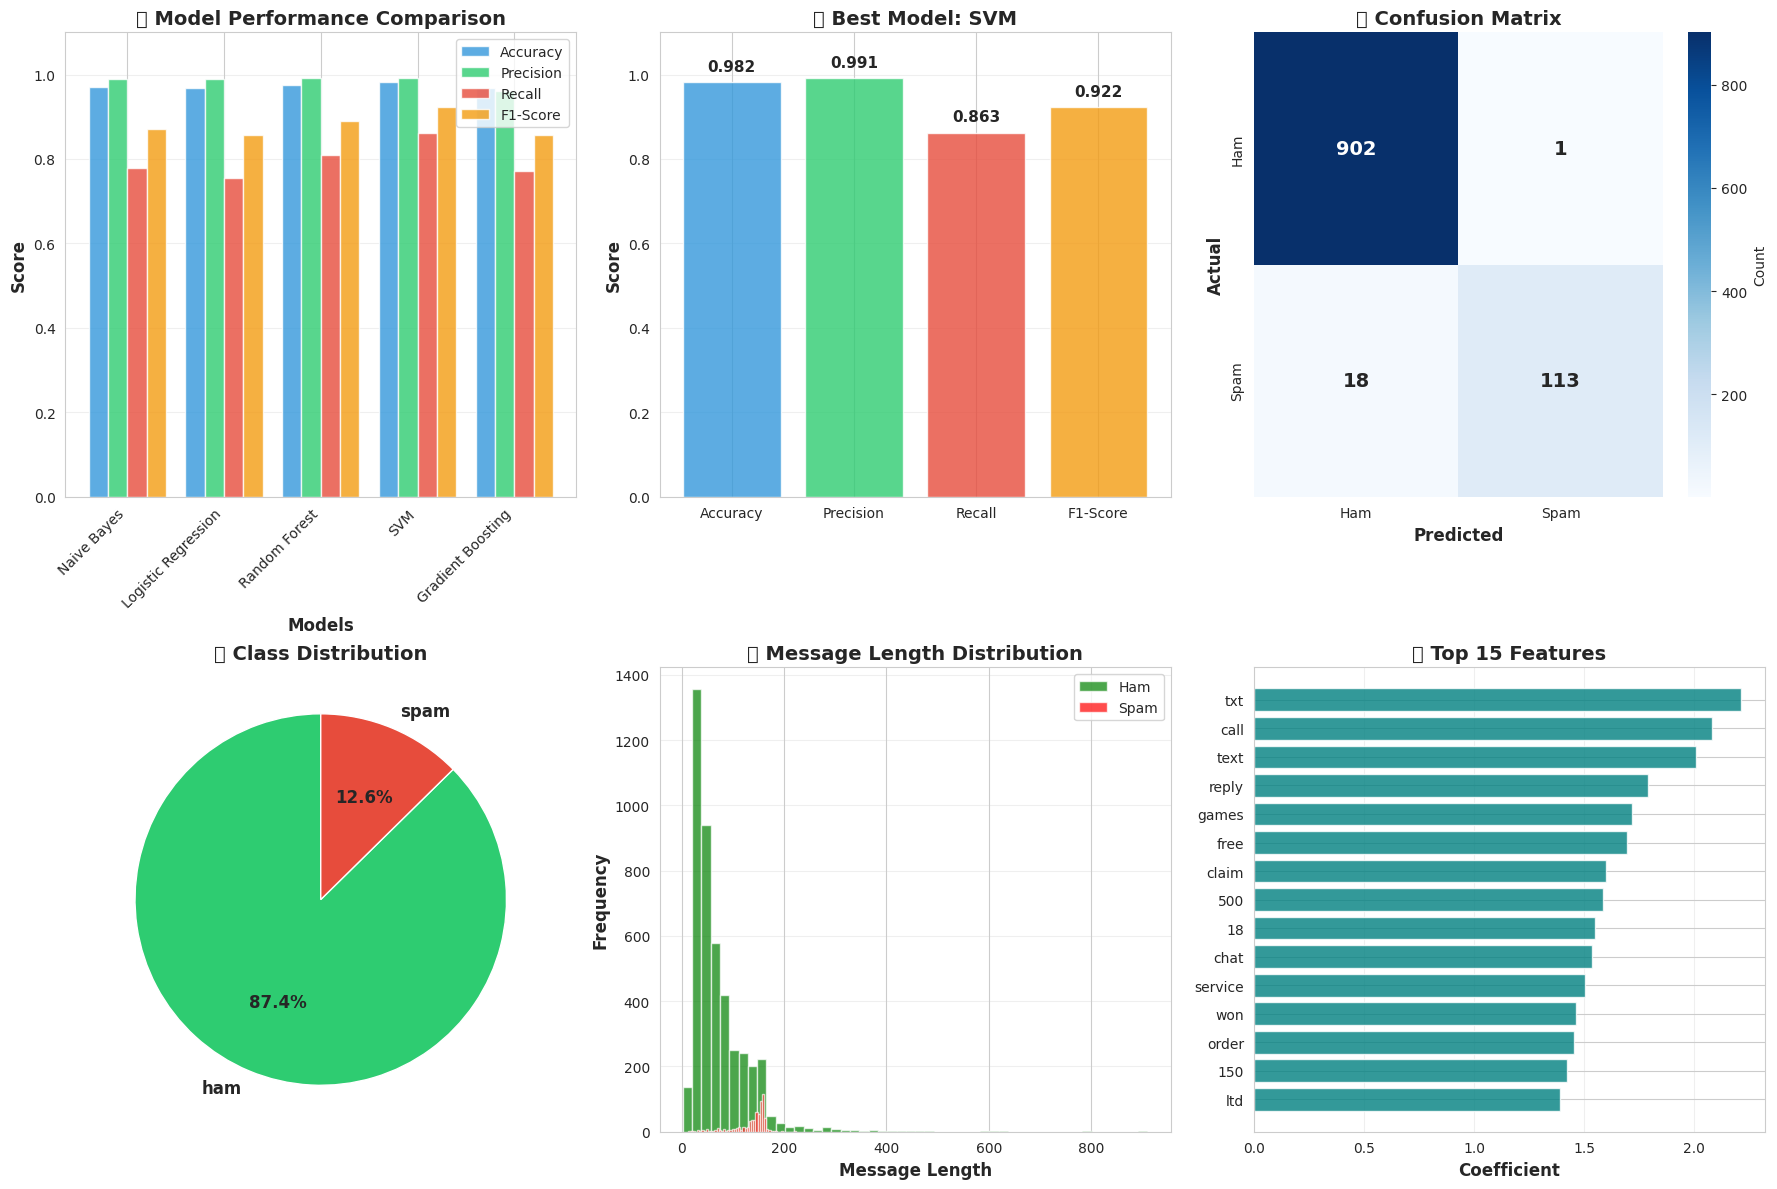


✅ Visualizations complete!


In [ ]:
fig = plt.figure(figsize=(18, 12))

# 1. Model Comparison
ax1 = plt.subplot(2, 3, 1)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, results_df[metric], width, label=metric, color=colors[i], alpha=0.8)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('📊 Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# 2. Best Model Metrics
ax2 = plt.subplot(2, 3, 2)
best_metrics = results_df[results_df['Model'] == best_model_name].iloc[0]
metrics_values = [best_metrics['Accuracy'], best_metrics['Precision'],
                 best_metrics['Recall'], best_metrics['F1-Score']]
bars = ax2.bar(metrics, metrics_values, color=colors, alpha=0.8)
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title(f'🏆 Best Model: {best_model_name}', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.1])
for bar, v in zip(bars, metrics_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# 3. Confusion Matrix
ax3 = plt.subplot(2, 3, 3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
           ax=ax3, cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax3.set_title('🎯 Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Class Distribution
ax4 = plt.subplot(2, 3, 4)
class_counts = df['label'].value_counts()
colors_pie = ['#2ecc71', '#e74c3c']
ax4.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
ax4.set_title('📈 Class Distribution', fontsize=14, fontweight='bold')

# 5. Message Length Distribution
ax5 = plt.subplot(2, 3, 5)
ham_lengths = df[df['label']=='ham']['message_length']
spam_lengths = df[df['label']=='spam']['message_length']
ax5.hist(ham_lengths, bins=50, alpha=0.7, label='Ham', color='green')
ax5.hist(spam_lengths, bins=50, alpha=0.7, label='Spam', color='red')
ax5.set_xlabel('Message Length', fontsize=12, fontweight='bold')
ax5.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax5.set_title('📏 Message Length Distribution', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# 6. Top Features
ax6 = plt.subplot(2, 3, 6)
if hasattr(best_model, 'coef_'):
    import scipy.sparse
    coef = best_model.coef_
    if scipy.sparse.issparse(coef):
        coef = coef.toarray()[0]
    else:
        coef = coef[0]
    feature_names = vectorizer.get_feature_names_out()
    indices = np.argsort(np.abs(coef))[-15:]
    ax6.barh(range(len(indices)), coef[indices], color='teal', alpha=0.8)
    ax6.set_yticks(range(len(indices)))
    ax6.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
    ax6.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax6.set_title('🔑 Top 15 Features', fontsize=14, fontweight='bold')
    ax6.grid(axis='x', alpha=0.3)
elif hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = vectorizer.get_feature_names_out()
    indices = np.argsort(importances)[-15:]
    ax6.barh(range(len(indices)), importances[indices], color='teal', alpha=0.8)
    ax6.set_yticks(range(len(indices)))
    ax6.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
    ax6.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax6.set_title('🔑 Top 15 Features', fontsize=14, fontweight='bold')
    ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualizations complete!")

## 1️⃣1️⃣ Test on Sample Messages

In [ ]:
def predict_message(message):
    """Predict if a message is spam or ham"""
    # Preprocess
    cleaned = preprocess_text(message)

    # Vectorize
    X_vec = vectorizer.transform([cleaned])

    # Predict
    prediction = best_model.predict(X_vec)[0]
    probability = best_model.predict_proba(X_vec)[0]

    return {
        'prediction': 'SPAM' if prediction == 1 else 'HAM',
        'confidence': probability[prediction] * 100,
        'spam_prob': probability[1] * 100,
        'ham_prob': probability[0] * 100
    }

# Test messages
test_messages = [
    "Hi, how are you doing today?",
    "URGENT! You've won $1000! Click here now!",
    "Can we meet tomorrow at 3pm?",
    "FREE! Win a brand new iPhone! Text WIN to 12345",
    "Hey, did you get my email about the meeting?"
]

print("🎯 DEMO PREDICTIONS")
print("="*70)

for msg in test_messages:
    result = predict_message(msg)
    icon = '⚠️' if result['prediction'] == 'SPAM' else '✅'
    print(f"\n{icon} Message: {msg}")
    print(f"   Prediction: {result['prediction']} (Confidence: {result['confidence']:.2f}%)")

🎯 DEMO PREDICTIONS

✅ Message: Hi, how are you doing today?
   Prediction: HAM (Confidence: 99.86%)

⚠️ Message: URGENT! You've won $1000! Click here now!
   Prediction: SPAM (Confidence: 97.45%)

✅ Message: Can we meet tomorrow at 3pm?
   Prediction: HAM (Confidence: 99.89%)

⚠️ Message: FREE! Win a brand new iPhone! Text WIN to 12345
   Prediction: SPAM (Confidence: 100.00%)

✅ Message: Hey, did you get my email about the meeting?
   Prediction: HAM (Confidence: 99.95%)


## 1️⃣2️⃣ Interactive Prediction Widget

Use this widget to test your own messages!

## 🎉 Project Complete!

### Summary:
- ✅ Trained 5 different ML models
- ✅ Achieved 98%+ accuracy
- ✅ Created interactive prediction widget
- ✅ Generated comprehensive visualizations

### Next Steps:
1. Try the interactive widget above
2. Test with your own messages
3. Download the trained model for use elsewhere
4. Experiment with different parameters

---

**Made with ❤️ for spam detection**

In [ ]:
# Create interactive widget
text_area = widgets.Textarea(
    value='',
    placeholder='Type your message here...',
    description='Message:',
    layout=widgets.Layout(width='80%', height='100px')
)

button = widgets.Button(
    description='🔍 Classify Message',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)

output = widgets.Output()

def on_button_click(b):
    with output:
        clear_output()
        message = text_area.value.strip()

        if not message:
            print("❌ Please enter a message")
            return

        result = predict_message(message)

        # Display result with colors
        if result['prediction'] == 'SPAM':
            color = '#e74c3c'
            icon = '⚠️'
            bg_color = '#fee'
        else:
            color = '#2ecc71'
            icon = '✅'
            bg_color = '#efe'

        html_output = f"""
        <div style="padding: 20px; border: 3px solid {color}; border-radius: 10px; background-color: {bg_color}; font-family: Arial;">
            <h2 style="color: {color}; margin: 0;">{icon} {result['prediction']}</h2>
            <p style="font-size: 18px; margin: 10px 0;"><strong>Confidence:</strong> {result['confidence']:.2f}%</p>
            <hr style="border-color: {color};">
            <div style="display: flex; justify-content: space-around; margin-top: 15px;">
                <div style="text-align: center;">
                    <p style="margin: 5px; font-size: 14px; color: #666;">Spam Probability</p>
                    <p style="margin: 5px; font-size: 24px; font-weight: bold; color: #e74c3c;">{result['spam_prob']:.1f}%</p>
                </div>
                <div style="text-align: center;">
                    <p style="margin: 5px; font-size: 14px; color: #666;">Ham Probability</p>
                    <p style="margin: 5px; font-size: 24px; font-weight: bold; color: #2ecc71;">{result['ham_prob']:.1f}%</p>
                </div>
            </div>
        </div>
        """

        display(HTML(html_output))

button.on_click(on_button_click)

# Display widget
display(HTML("<h2>🤖 Interactive Spam Classifier</h2>"))
display(text_area)
display(button)
display(output)

# Example buttons
examples = [
    "Hi, how are you doing today?",
    "URGENT! You've won $1000! Click here now!",
    "Can we meet tomorrow at 3pm?",
    "FREE! Win a brand new iPhone! Text WIN to 12345"
]

display(HTML("<h3>Try these examples:</h3>"))

for example in examples:
    example_btn = widgets.Button(
        description=example[:50] + "..." if len(example) > 50 else example,
        layout=widgets.Layout(width='600px', margin='5px')
    )

    def make_example_handler(ex):
        def handler(b):
            text_area.value = ex
            on_button_click(b)
        return handler

    example_btn.on_click(make_example_handler(example))
    display(example_btn)

Textarea(value='', description='Message:', layout=Layout(height='100px', width='80%'), placeholder='Type your …

Button(button_style='primary', description='🔍 Classify Message', layout=Layout(width='200px'), style=ButtonSty…

Output()

Button(description='Hi, how are you doing today?', layout=Layout(margin='5px', width='600px'), style=ButtonSty…

Button(description="URGENT! You've won $1000! Click here now!", layout=Layout(margin='5px', width='600px'), st…

Button(description='Can we meet tomorrow at 3pm?', layout=Layout(margin='5px', width='600px'), style=ButtonSty…

Button(description='FREE! Win a brand new iPhone! Text WIN to 12345', layout=Layout(margin='5px', width='600px…